###  Nassau Candy Distributor: Factory Reallocation & Optimization

In [96]:
# required libraries
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans

### Load Dataset

In [97]:
df = pd.read_csv(r"C:\united_inteship\Un_project\Nassau Candy Distributor.csv")

In [98]:
# Top 5 row show 
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [99]:
# Dataset shape
df.shape

(10194, 18)

In [100]:
# Dataset datatype information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [101]:
# statistics analysis 
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [102]:
# Check of missing value 
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

### Feature Engineering

In [103]:
# Convert Dates to datetime Object 
df['Order Date'] = pd.to_datetime(df['Order Date'],format='%d-%m-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],format='%d-%m-%Y', errors='coerce')

# calculate leadtime / shipping duration 
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

In [104]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Duration
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912


###  Data Cleaning

In [105]:
df = df.dropna()
df.isnull().sum()

Row ID               0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Country/Region       0
City                 0
State/Province       0
Postal Code          0
Division             0
Region               0
Product ID           0
Product Name         0
Sales                0
Units                0
Gross Profit         0
Cost                 0
Shipping Duration    0
dtype: int64

### EDA (Visualization)

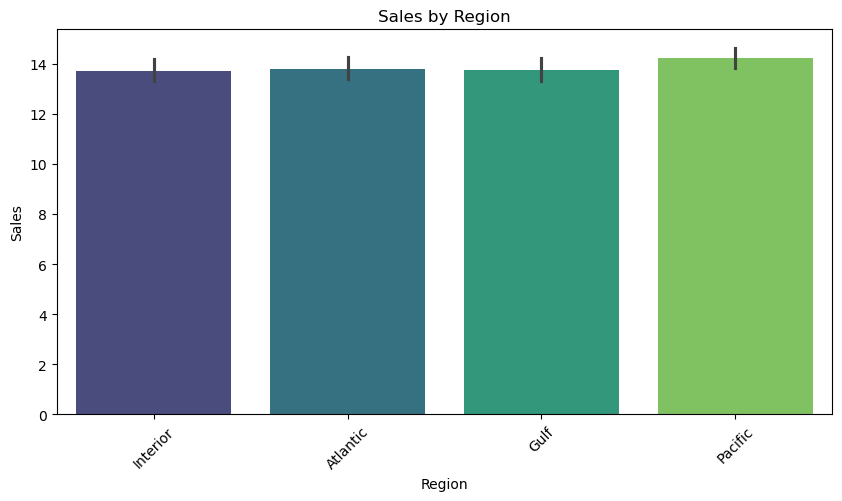

In [106]:
# Sales by Region 
plt.figure(figsize=(10,5))
sns.barplot(data=df, x = 'Region', y='Sales',palette='viridis')
plt.title('Sales by Region')
plt.xticks(rotation = 45)
plt.show()

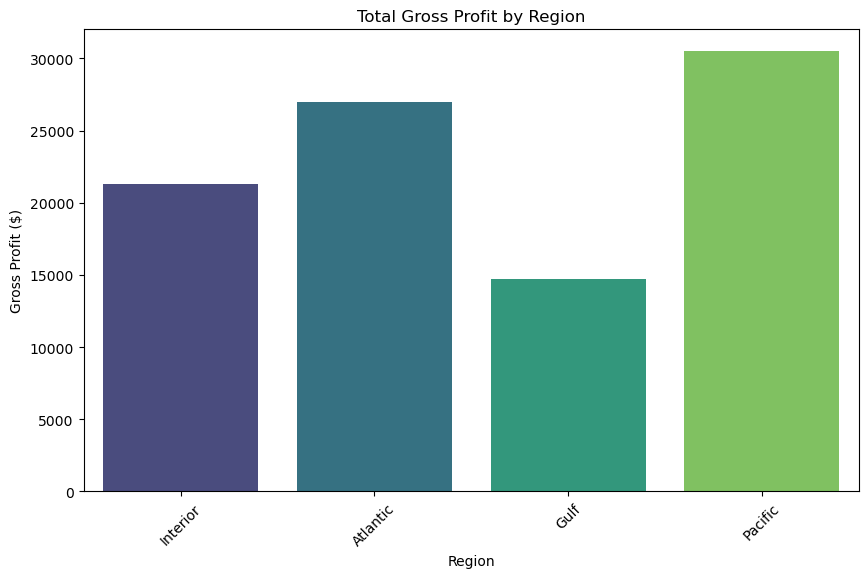

In [107]:
# Visualizing profitability across regions
plt.figure(figsize=(10,6))
sns.barplot(data=df, x = 'Region', y = 'Gross Profit', estimator=sum, ci=None, palette = 'viridis')
plt.title('Total Gross Profit by Region')
plt.xlabel('Region')
plt.ylabel('Gross Profit ($)')
plt.xticks(rotation = 45)
plt.show()

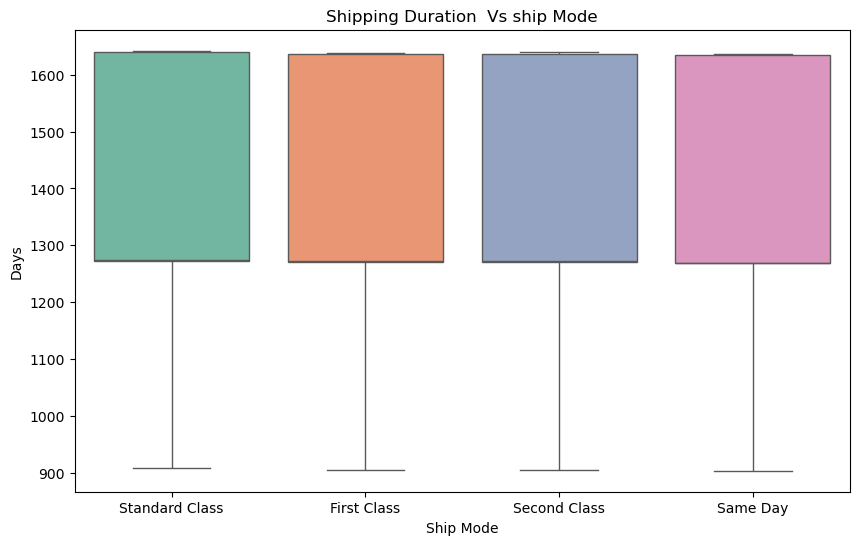

In [108]:
# Analzing Shipping duration  against shiping model
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x = 'Ship Mode',y='Shipping Duration', palette='Set2')
plt.title('Shipping Duration  Vs ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Days')
plt.show()

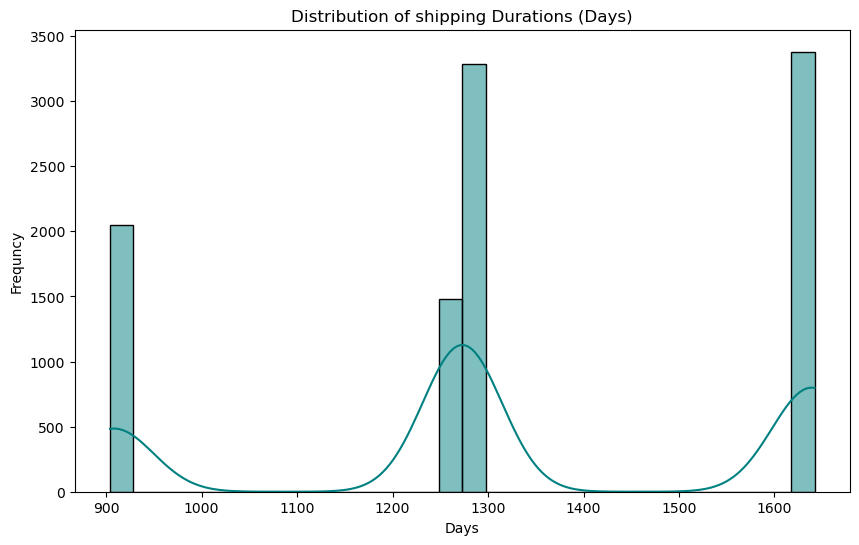

In [109]:
# Visualizing the distribution of shipping days.
plt.figure(figsize=(10,6))
sns.histplot(df['Shipping Duration'],bins=30, kde=True, color='teal')
plt.title('Distribution of shipping Durations (Days)')
plt.xlabel('Days')
plt.ylabel('Frequncy')
plt.show()

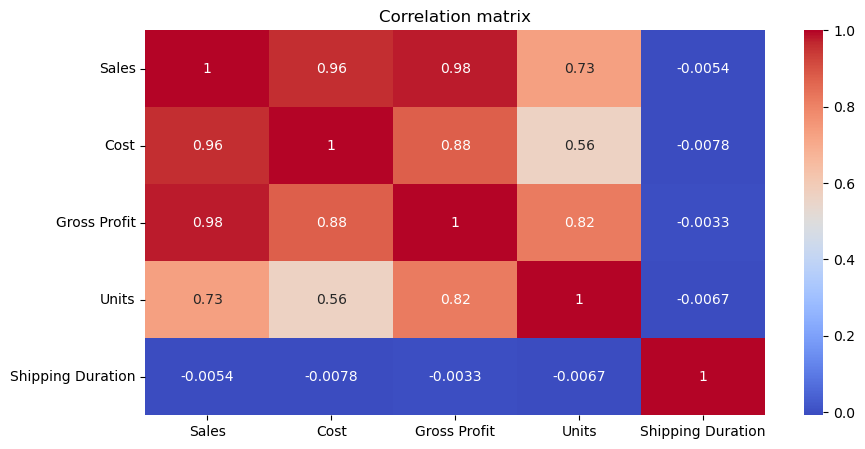

In [110]:
#Correlation Heatmap 
plt.figure(figsize=(10,5))
sns.heatmap(df[['Sales','Cost','Gross Profit','Units','Shipping Duration']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

### Encoding + Scaling

In [111]:
print('Unique columns',df['Region'].value_counts())

Unique columns Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64


In [112]:
print("Unique value for ship mode", df['Ship Mode'].value_counts())

Unique value for ship mode Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64


In [113]:
print('unique vlues in',df['Division'].value_counts())

unique vlues in Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64


In [114]:
print('product Names',df['Product Name'].value_counts())

product Names Product Name
Wonka Bar - Milk Chocolate           2137
Wonka Bar -Scrumdiddlyumptious       2064
Wonka Bar - Triple Dazzle Caramel    2015
Wonka Bar - Fudge Mallows            1818
Wonka Bar - Nutty Crunch Surprise    1810
Wonka Gum                             120
Kazookles                              96
Lickable Wallpaper                     94
Laffy Taffy                            10
SweeTARTS                              10
Fizzy Lifting Drinks                    6
Nerds                                   4
Hair Toffee                             4
Everlasting Gobstopper                  3
Fun Dip                                 3
Name: count, dtype: int64


In [115]:
le = LabelEncoder()

categorical_cols = ['Region', 'Ship Mode', 'Division', 'Product Name']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [116]:
scaler = StandardScaler()

num_cols = ['Sales','Cost','Gross Profit','Units']
df[num_cols] = scaler.fit_transform(df[num_cols])

### Model Preparation

In [117]:
X = df[['Region', 'Ship Mode', 'Division', 'Product Name', 'Sales', 'Cost', 'Gross Profit']]
y = df['Shipping Duration']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=20, random_state=42)

In [118]:
X_train.head()

,Region,Ship Mode,Division,Product Name,Sales,Cost,Gross Profit
4813,0,3,0,10,1.066223,0.864961,1.161082
4829,2,3,0,9,1.630574,1.196885,1.871560
3053,2,3,0,13,-0.909005,-0.719581,-1.003468
3288,0,2,0,10,-0.653283,-0.486444,-0.744565
2589,1,2,0,12,-0.895778,-0.680066,-1.010994


In [119]:
y_train.head()

4813    1274
4829    1274
3053    1273
3288    1272
2589    1272
Name: Shipping Duration, dtype: int64

###  Models

In [120]:
# Linear Regression 
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [121]:
# Gradient Boostingab
gb  = GradientBoostingRegressor()
gb.fit(X_train,y_train)
y_pred_gb = gb.predict(X_test)

In [122]:
# Random Forest 
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### Model Evaluation

In [123]:
def evaluate(y_test, y_pred,name): 
    print(f"\n{name}")
    print("MAE:",mean_absolute_error(y_test, y_pred))
    print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
    print('R2:', r2_score(y_test, y_pred))


evaluate(y_test, y_pred_lr, 'Linear Regression')
evaluate(y_test, y_pred_rf, 'Random Forest')
evaluate(y_test, y_pred_gb, "Gradient Boosting")


Linear Regression
MAE: 147.521777136436
RMSE: 201.3558082844426
R2: -0.05094333232084858

Random Forest
MAE: 175.6586692435722
RMSE: 228.08683631745134
R2: -0.34850145202841687

Gradient Boosting
MAE: 152.96297471608878
RMSE: 207.82393541716738
R2: -0.11954641784483844


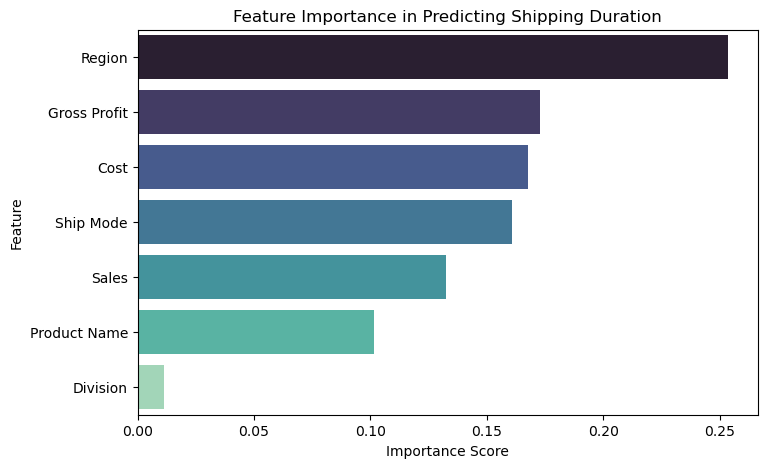

In [124]:
# Visualizing Feature Importance for model Random Forest 
importance = rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='mako')
plt.title('Feature Importance in Predicting Shipping Duration')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

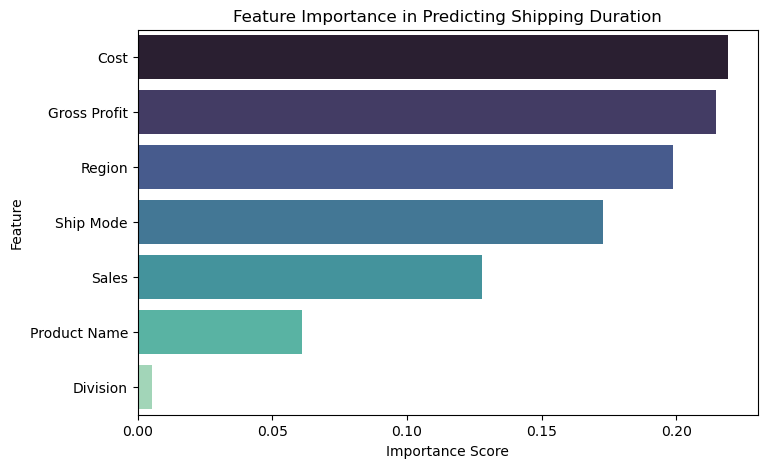

In [125]:
# Visualizing Feature Importance for Gradient Boostingab
importance = gb.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='mako')
plt.title('Feature Importance in Predicting Shipping Duration')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

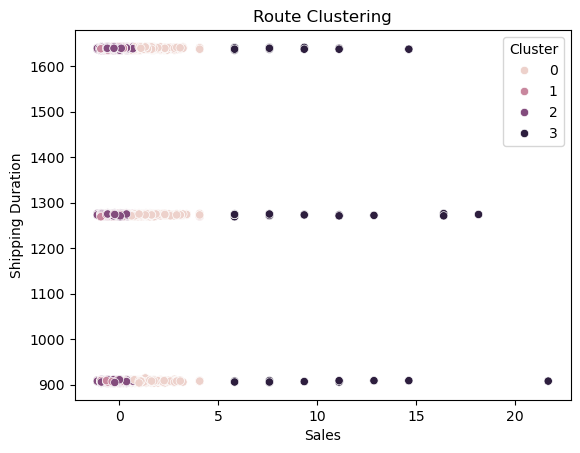

In [126]:
# Clustering (Route Ana
kmeans = KMeans(n_clusters=4)
df['Cluster'] = kmeans.fit_predict(X)

sns.scatterplot(x=df['Sales'], y=df['Shipping Duration'], hue=df['Cluster'])
plt.title("Route Clustering")
plt.show()

In [127]:
def simulate(product, region, ship_mode, model):
    
    temp = df.copy()
    
    # Filter product
    temp = temp[temp['Product Name'] == product]
    
    results = []
    
    for factory in temp['Division'].unique():
        
        sample = temp.iloc[0:1].copy()
        sample['Division'] = factory
        sample['Region'] = region
        sample['Ship Mode'] = ship_mode
        
        pred = model.predict(sample[X.columns])[0]
        
        results.append((factory, pred))
    
    return pd.DataFrame(results, columns=['Factory','Predicted Lead Time'])

In [128]:
def recommend(product, region, ship_mode, model):
    
    sim = simulate(product, region, ship_mode, model)
    
    sim = sim.sort_values(by='Predicted Lead Time')
    
    return sim.head(3)

In [129]:
recommend(product=1, region=2, ship_mode=0, model=rf)

,Factory,Predicted Lead Time
0,2,1118.19966


In [131]:
# Identify Slow Routes
slow_routes = df.groupby(['Region','Product Name'])['Shipping Duration'].mean().reset_index()

slow_routes = slow_routes.sort_values(by='Shipping Duration', ascending=False)

print("Top Slow Routes:")
print(slow_routes.head(10))

Top Slow Routes:
    Region  Product Name  Shipping Duration
27       2             0        1641.000000
2        0             3        1639.000000
46       3             8        1638.000000
44       3             5        1638.000000
17       1             3        1635.000000
4        0             5        1456.166667
0        0             1        1455.500000
5        0             6        1387.828571
33       2             8        1364.750000
10       0            11        1360.426531


In [132]:
# Identify Congested Combinations
congestion = df.groupby(['Region','Product Name']).agg({
    'Units':'sum',
    'Shipping Duration':'mean'
}).reset_index()

congestion = congestion.sort_values(by=['Units','Shipping Duration'], ascending=False)

print("Congested Routes:")
print(congestion.head(10))

Congested Routes:
    Region  Product Name      Units  Shipping Duration
48       3            10  81.067703        1326.024024
22       1            10  41.880225        1289.732733
47       3             9  32.063434        1314.434095
34       2             9  18.107057        1311.570732
50       3            12  14.234439        1332.133136
13       0            14  12.881198        1312.756757
25       1            13  12.355274        1314.545161
26       1            14   9.609609        1343.692308
45       3             6   7.664231        1305.529412
32       2             6   6.338020        1321.466667


In [133]:
#Add Factory Mapping
factory_map = {
    'Chocolate': "Lot's O' Nuts",
    'Sugar': "Sugar Shack",
    'Other': "Secret Factory"
}

df['Factory'] = df['Division'].map(factory_map)

In [134]:
def simulate_factory(product, region, ship_mode, model):
    
    factories = df['Factory'].unique()
    results = []

    for factory in factories:
        
        sample = df.sample(1).copy()

        sample['Product Name'] = product
        sample['Region'] = region
        sample['Ship Mode'] = ship_mode
        sample['Factory'] = factory
        
        pred_time = model.predict(sample[X.columns])[0]
        
        results.append({
            'Factory': factory,
            'Predicted Lead Time': pred_time
        })
    
    return pd.DataFrame(results)

In [135]:
#OPERATIONAL IMPROVEMENT + PROFIT IMPACT 
def evaluate_scenario(sim_df, current_time):
    
    sim_df['Lead Time Reduction'] = current_time - sim_df['Predicted Lead Time']
    
    sim_df['Improvement %'] = (sim_df['Lead Time Reduction'] / current_time) * 100
    
    return sim_df

In [136]:
#Profit Sensitivity
def profit_impact(df, product):
    
    temp = df[df['Product Name'] == product]
    
    avg_profit = temp['Gross Profit'].mean()
    
    return avg_profit

In [137]:
# OPTIMIZATION & RECOMMENDATION ENGINE
def recommend_factory(product, region, ship_mode, model):
    
    sim = simulate_factory(product, region, ship_mode, model)
    
    current_time = df['Shipping Duration'].mean()
    
    sim = evaluate_scenario(sim, current_time)
    
    sim['Score'] = (
        sim['Improvement %'] * 0.6 +
        (1 / sim['Predicted Lead Time']) * 0.4
    )
    
    sim = sim.sort_values(by='Score', ascending=False)
    
    return sim.head(3)

### KPI SYSTEM

In [140]:
#Lead Time Reduction
def lead_time_kpi(old, new):
    return ((old - new) / old) * 100

In [139]:
# Profit Stability
def profit_stability(df):
    return df['Gross Profit'].std()

In [141]:
#Scenario Confidence Score
def confidence_score(model, X_test, y_test):
    return model.score(X_test, y_test)

In [142]:
#Recommendation Coverage 
def coverage(df):
    return df['Product Name'].nunique()

In [143]:
result = recommend_factory(
    product=1, 
    region=2, 
    ship_mode=0, 
    model=rf
)

print(result)

   Factory  Predicted Lead Time  Lead Time Reduction  Improvement %     Score
0      NaN          1219.249345           101.592523       7.691498  4.615227


### 